In [1]:
import numpy as np
import xarray as xr

import matplotlib.pyplot as plt
import cmocean as cm
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.ticker as mticker

In [36]:
DATA_DIR = "/Volumes/PortableSSD/"
GDP_FILE = "gdp_energy.nc"
SWOT_FILE = "diags_2024/swot_segments2D_250km_demean_swh5.nc"

In [37]:
ds_gdp = xr.open_dataset(DATA_DIR+GDP_FILE)
ds_ex = xr.open_dataset(DATA_DIR+SWOT_FILE)

In [38]:
def build_box_dataset(ds_segments: xr.Dataset,
                      box_deg: float = 2.0,
                      psd_var: str = 'psd',
                      min_sampling_fraction: float = 0.5) -> xr.Dataset:
    from collections import defaultdict
    lat     = ds_segments['lat_mean'].values
    lon     = ds_segments['lon_mean'].values
    lat_idx = np.floor(lat / box_deg).astype(int)
    lon_idx = np.floor(lon / box_deg).astype(int)
    box_to_segs = defaultdict(list)
    for i, key in enumerate(zip(lat_idx, lon_idx)):
        box_to_segs[key].append(i)
    psd_all    = ds_segments[psd_var].values
    wavenumber = ds_segments['wavenumber'].values
    rows_lat, rows_lon, rows_n, rows_psd = [], [], [], []
    for (li, loi), idxs in sorted(box_to_segs.items()):
        rows_psd.append(np.nanmean(psd_all[idxs, :], axis=0))
        rows_n.append(len(idxs))
        rows_lat.append((li  + 0.5) * box_deg)
        rows_lon.append((loi + 0.5) * box_deg)
    n_segments = np.array(rows_n)
    n_max      = n_segments.max()
    keep       = n_segments >= min_sampling_fraction * n_max
    psd_stack  = np.stack(rows_psd, axis=0)
    lat_mean   = np.array(rows_lat)
    lon_mean   = np.array(rows_lon)
    return xr.Dataset(
        data_vars=dict(
            mean_psd=(['box', 'wavenumber'], psd_stack[keep],
                      {'long_name': 'Box-mean SSH(A) PSD', 'units': 'm^2 / (cycles/km)'}),
            n_segments=(['box'], n_segments[keep]),
            sampling_fraction=(['box'], n_segments[keep] / n_max),
        ),
        coords=dict(wavenumber=('wavenumber', wavenumber, {'units': 'cycles/km'}),
            box=('box', np.arange(keep.sum())),
            lat_mean=('box', lat_mean[keep], {'units': 'degrees_north'}),
            lon_mean=('box', lon_mean[keep], {'units': 'degrees_east'}),
        ),
        attrs=dict(box_size_deg=box_deg,
                   min_sampling_fraction=min_sampling_fraction),
    )

In [39]:
ds_box_ex = build_box_dataset(ds_ex,box_deg = 2.0)
ds_box_ex

<xarray.Dataset> Size: 4MB
Dimensions:            (box: 6968, wavenumber: 63)
Coordinates:
  * box                (box) int64 56kB 0 1 2 3 4 5 ... 6963 6964 6965 6966 6967
    lat_mean           (box) float64 56kB -59.0 -59.0 -59.0 ... 59.0 59.0 59.0
    lon_mean           (box) float64 56kB 1.0 5.0 7.0 17.0 ... 349.0 351.0 359.0
  * wavenumber         (wavenumber) float64 504B 0.0 0.003998 ... 0.2439 0.2479
Data variables:
    mean_psd           (box, wavenumber) float64 4MB 0.006919 ... 1.53e-05
    n_segments         (box) int64 56kB 133 126 130 130 137 ... 133 157 153 165
    sampling_fraction  (box) float64 56kB 0.5429 0.5143 0.5306 ... 0.6245 0.6735
Attributes:
    box_size_deg:           2.0
    min_sampling_fraction:  0.5

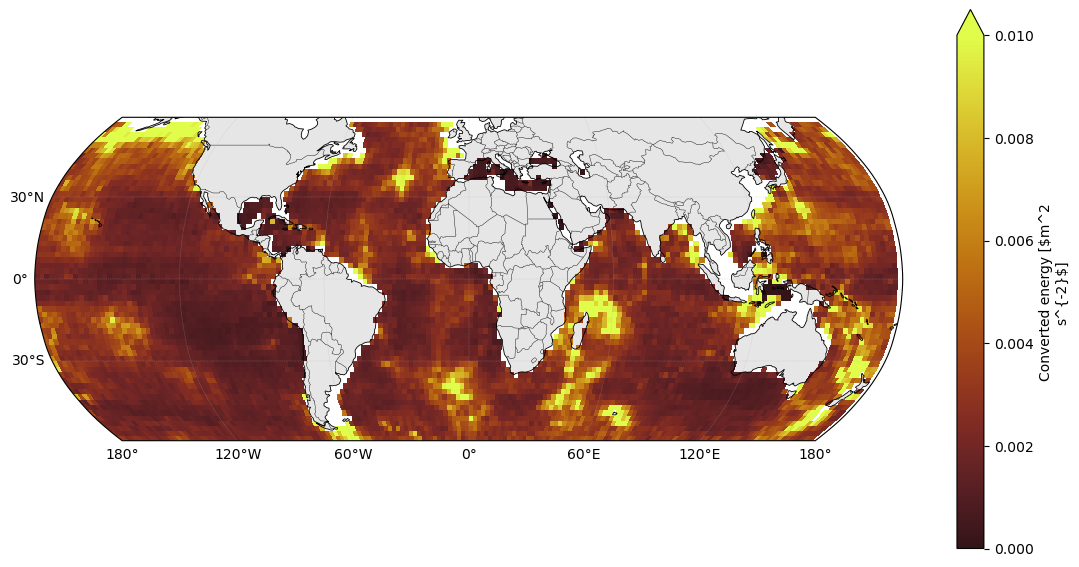

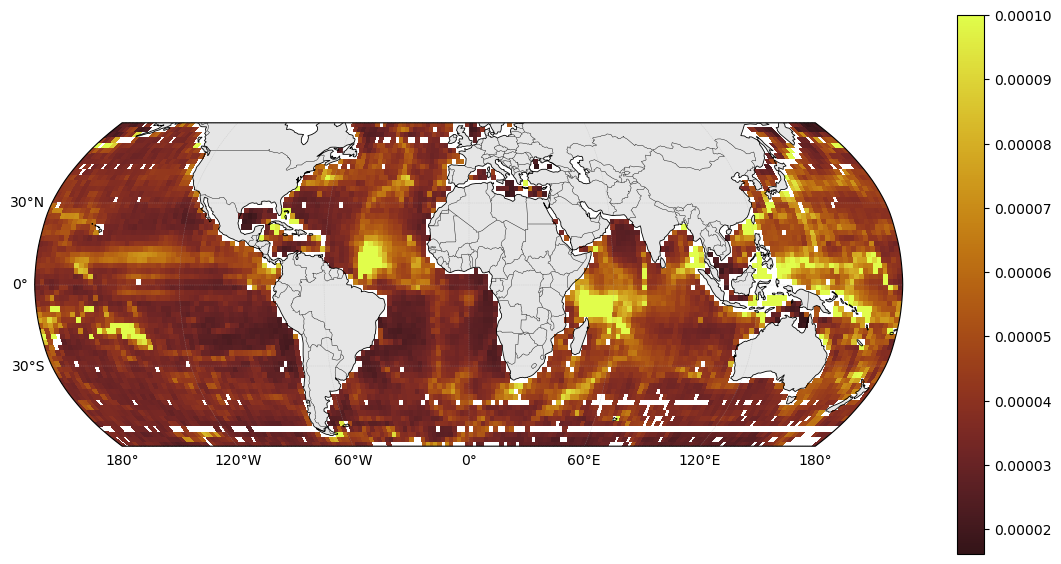

In [40]:
#GDP kinetic energy
fig = plt.figure(figsize=(14,7))
ax = plt.axes(projection=ccrs.Robinson())
ax.set_global()
ax.add_feature(cfeature.LAND, facecolor="0.9", edgecolor="none")
ax.add_feature(cfeature.COASTLINE, linewidth=0.6)
ax.add_feature(cfeature.BORDERS, linewidth=0.3)
gl = ax.gridlines(draw_labels=True, linewidth=0.3, linestyle="--", alpha=0.5)

gl.top_labels = False
gl.right_labels = False
gl.xlocator = mticker.FixedLocator(np.arange(-180, 181, 60))
gl.ylocator = mticker.FixedLocator(np.arange(-60, 61, 30))
gl.xlabel_style = {"size": 10, "color": "black"}
gl.ylabel_style = {"size": 10, "color": "black"}
#ax.scatter(ds_gdp.lon, ds_gdp.lat, c=ds_gdp.E_energy,transform=ccrs.PlateCarree())
ds_gdp.E_energy.T.plot(ax=ax,transform=ccrs.PlateCarree(),cmap=cm.cm.solar,vmax=1e-2)
ax.set_extent([-180,180,-60,60])


# SWOT Expert integrated spectra
energy = ds_box_ex.mean_psd.sel(wavenumber=slice(1/50,None)).integrate('wavenumber')
# Reconstruct the regular grid of box centers
if True:
    lat = energy.lat_mean
    lon = energy.lon_mean
    lat_centers = np.arange(lat.min(), lat.max() + 2.0, 2.0)
    lon_centers = np.arange(lon.min(), lon.max() + 2.0, 2.0)

    lat_idx = np.round((lat - lat_centers[0]) / 2.0).astype(int)
    lon_idx = np.round((lon - lon_centers[0]) / 2.0).astype(int)

    grid = np.full((lat_centers.size, lon_centers.size), np.nan)
    grid[lat_idx, lon_idx] = energy

    # pcolormesh wants cell edges, not centers
    lat_edges = np.concatenate([lat_centers - 2.0 / 2, [lat_centers[-1] + 2.0 / 2]])
    lon_edges = np.concatenate([lon_centers - 2.0 / 2, [lon_centers[-1] + 2.0 / 2]])

fig = plt.figure(figsize=(14,7))
ax = plt.axes(projection=ccrs.Robinson())
ax.set_global()
ax.add_feature(cfeature.LAND, facecolor="0.9", edgecolor="none")
ax.add_feature(cfeature.COASTLINE, linewidth=0.6)
ax.add_feature(cfeature.BORDERS, linewidth=0.3)
gl = ax.gridlines(draw_labels=True, linewidth=0.3, linestyle="--", alpha=0.5)

gl.top_labels = False
gl.right_labels = False
gl.xlocator = mticker.FixedLocator(np.arange(-180, 181, 60))
gl.ylocator = mticker.FixedLocator(np.arange(-60, 61, 30))
gl.xlabel_style = {"size": 10, "color": "black"}
gl.ylabel_style = {"size": 10, "color": "black"}
#sc = ax.pcolormesh(ds_box_ex.lon_mean, ds_box_ex.lat_mean, energy,transform=ccrs.PlateCarree(),cmap=cm.cm.solar,vmax=1e-4)
sc = ax.pcolormesh(lon_edges,lat_edges, grid,transform=ccrs.PlateCarree(),cmap=cm.cm.solar,vmax=1e-4)
#ds_ex..plot(ax=ax,transform=ccrs.PlateCarree(),cmap=cm.cm.solar,vmax=1e-2)
plt.colorbar(sc, ax=ax)
ax.set_extent([-180,180,-60,60])

In [41]:
print(ds_gdp.E_energy.T.shape, grid[:,:-1].shape)

(60, 179) (60, 179)


In [42]:
lon_centers = lon_centers-180

In [43]:
omega_M2 = 1.932 #cycles per day
fc = 2*7.29e-5*np.sin(lat_centers*np.pi/180)*3600*24/2/np.pi
ratio = (omega_M2**2-fc**2)/(omega_M2**2+fc**2)

In [50]:
PE = 2*ds_gdp.E_energy*ratio

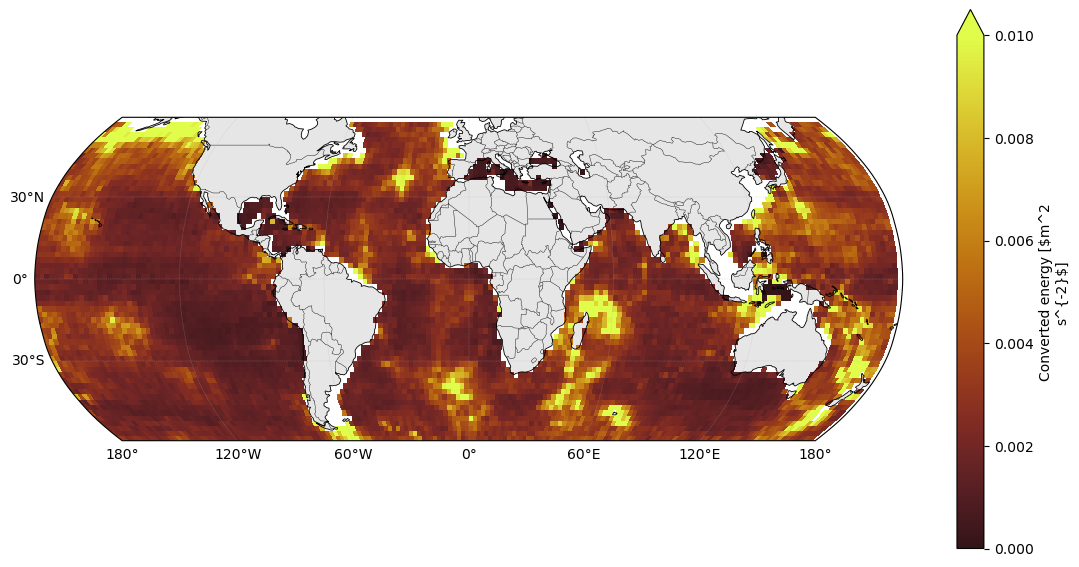

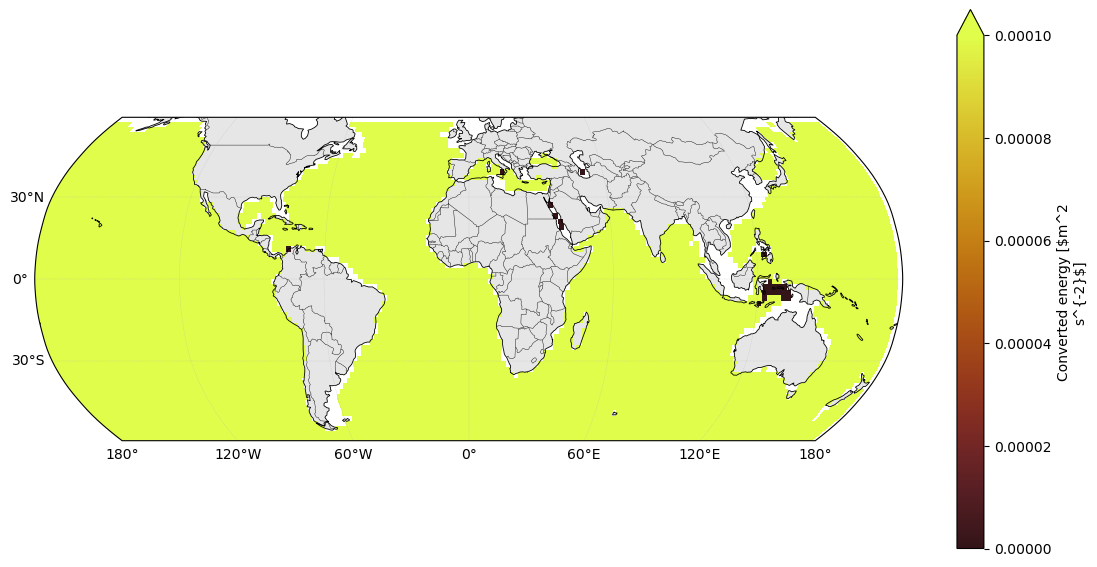

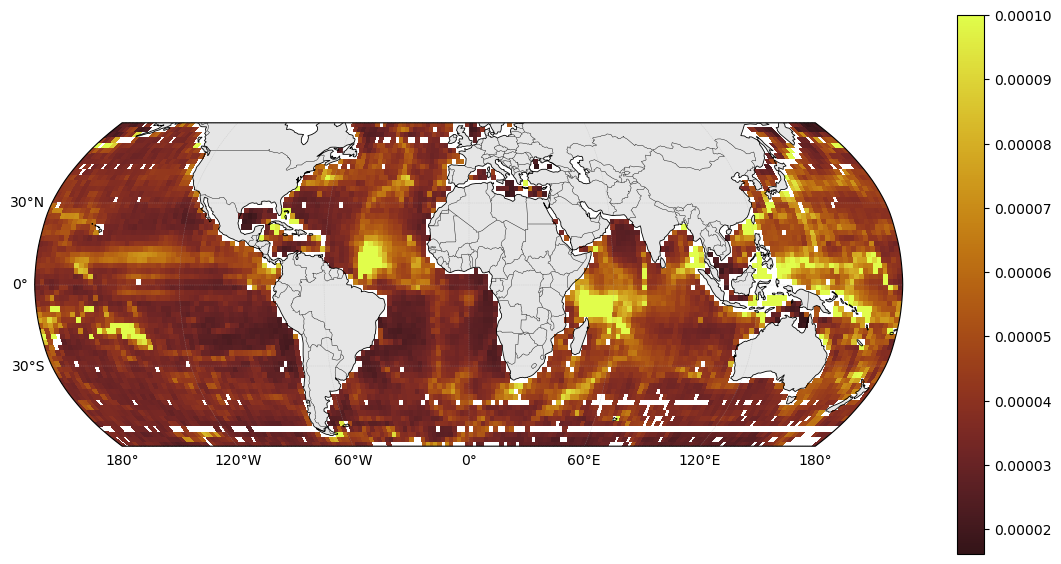

In [51]:
#GDP kinetic energy
fig = plt.figure(figsize=(14,7))
ax = plt.axes(projection=ccrs.Robinson())
ax.set_global()
ax.add_feature(cfeature.LAND, facecolor="0.9", edgecolor="none")
ax.add_feature(cfeature.COASTLINE, linewidth=0.6)
ax.add_feature(cfeature.BORDERS, linewidth=0.3)
gl = ax.gridlines(draw_labels=True, linewidth=0.3, linestyle="--", alpha=0.5)

gl.top_labels = False
gl.right_labels = False
gl.xlocator = mticker.FixedLocator(np.arange(-180, 181, 60))
gl.ylocator = mticker.FixedLocator(np.arange(-60, 61, 30))
gl.xlabel_style = {"size": 10, "color": "black"}
gl.ylabel_style = {"size": 10, "color": "black"}
#ax.scatter(ds_gdp.lon, ds_gdp.lat, c=ds_gdp.E_energy,transform=ccrs.PlateCarree())
ds_gdp.E_energy.T.plot(ax=ax,transform=ccrs.PlateCarree(),cmap=cm.cm.solar,vmax=1e-2)
ax.set_extent([-180,180,-60,60])

#GDP PE
fig = plt.figure(figsize=(14,7))
ax = plt.axes(projection=ccrs.Robinson())
ax.set_global()
ax.add_feature(cfeature.LAND, facecolor="0.9", edgecolor="none")
ax.add_feature(cfeature.COASTLINE, linewidth=0.6)
ax.add_feature(cfeature.BORDERS, linewidth=0.3)
gl = ax.gridlines(draw_labels=True, linewidth=0.3, linestyle="--", alpha=0.5)

gl.top_labels = False
gl.right_labels = False
gl.xlocator = mticker.FixedLocator(np.arange(-180, 181, 60))
gl.ylocator = mticker.FixedLocator(np.arange(-60, 61, 30))
gl.xlabel_style = {"size": 10, "color": "black"}
gl.ylabel_style = {"size": 10, "color": "black"}
#ax.scatter(ds_gdp.lon, ds_gdp.lat, c=ds_gdp.E_energy,transform=ccrs.PlateCarree())
PE.T.plot(ax=ax,transform=ccrs.PlateCarree(),cmap=cm.cm.solar,vmax=1e-4)
ax.set_extent([-180,180,-60,60])


# SWOT Expert integrated spectra
energy = ds_box_ex.mean_psd.sel(wavenumber=slice(1/50,None)).integrate('wavenumber')
# Reconstruct the regular grid of box centers
if True:
    lat = energy.lat_mean
    lon = energy.lon_mean
    lat_centers = np.arange(lat.min(), lat.max() + 2.0, 2.0)
    lon_centers = np.arange(lon.min(), lon.max() + 2.0, 2.0)

    lat_idx = np.round((lat - lat_centers[0]) / 2.0).astype(int)
    lon_idx = np.round((lon - lon_centers[0]) / 2.0).astype(int)

    grid = np.full((lat_centers.size, lon_centers.size), np.nan)
    grid[lat_idx, lon_idx] = energy

    # pcolormesh wants cell edges, not centers
    lat_edges = np.concatenate([lat_centers - 2.0 / 2, [lat_centers[-1] + 2.0 / 2]])
    lon_edges = np.concatenate([lon_centers - 2.0 / 2, [lon_centers[-1] + 2.0 / 2]])

fig = plt.figure(figsize=(14,7))
ax = plt.axes(projection=ccrs.Robinson())
ax.set_global()
ax.add_feature(cfeature.LAND, facecolor="0.9", edgecolor="none")
ax.add_feature(cfeature.COASTLINE, linewidth=0.6)
ax.add_feature(cfeature.BORDERS, linewidth=0.3)
gl = ax.gridlines(draw_labels=True, linewidth=0.3, linestyle="--", alpha=0.5)

gl.top_labels = False
gl.right_labels = False
gl.xlocator = mticker.FixedLocator(np.arange(-180, 181, 60))
gl.ylocator = mticker.FixedLocator(np.arange(-60, 61, 30))
gl.xlabel_style = {"size": 10, "color": "black"}
gl.ylabel_style = {"size": 10, "color": "black"}
#sc = ax.pcolormesh(ds_box_ex.lon_mean, ds_box_ex.lat_mean, energy,transform=ccrs.PlateCarree(),cmap=cm.cm.solar,vmax=1e-4)
sc = ax.pcolormesh(lon_edges,lat_edges, grid,transform=ccrs.PlateCarree(),cmap=cm.cm.solar,vmax=1e-4)
#ds_ex..plot(ax=ax,transform=ccrs.PlateCarree(),cmap=cm.cm.solar,vmax=1e-2)
plt.colorbar(sc, ax=ax)
ax.set_extent([-180,180,-60,60])

(0.0, 0.001)

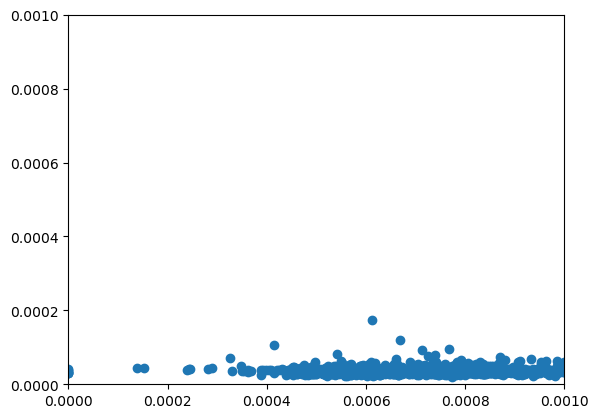

In [52]:
plt.scatter(PE.T,grid[:,:-1])
plt.ylim(0,1e-3);plt.xlim(0,1e-3)

Text(0, 0.5, 'HKE, GDP')

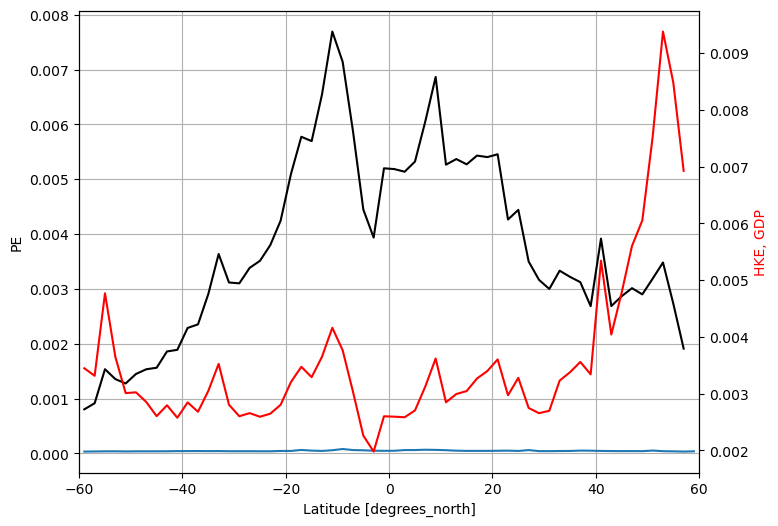

In [53]:
fig,ax = plt.subplots(figsize=(8,6))
PE.mean('lon').plot(ax=ax,c='k')
ax1 = ax.twinx()
ds_gdp.E_energy.mean('lon').plot(ax=ax1,c='r')
ax.plot(lat_centers,np.nanmean(grid,axis=1))
ax.grid();
ax.set_xlim(-60,60);
ax.set_ylabel('PE')
ax1.set_ylabel('HKE, GDP',c='r')

In [55]:
energy['lon_mean'] = energy.lon_mean-180

ValueError: Dimensions {'box'} do not exist. Expected one or more of FrozenMappingWarningOnValuesAccess({'lat': 60, 'lon': 179})

ValueError: x and y must be the same size

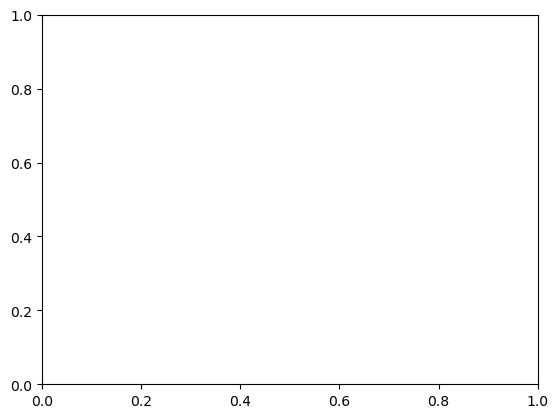

In [45]:
plt.scatter(ds_gdp.E_energy,ds_box_ex.mean_psd)